# Matplotlib 和 Seaborn 学习笔记

这个 notebook 把 Matplotlib 和 Seaborn 放在同一个文件里学习。

- Matplotlib：Python 里最基础、最灵活的绘图库，适合精细控制图表。
- Seaborn：基于 Matplotlib 的统计可视化库，更适合快速绘制美观的统计图。

建议先学 Matplotlib 的基本结构，再学 Seaborn 的高级图表。


## 一、导入库和准备数据

可视化常常和 NumPy、pandas 一起使用。这里先创建一份销售示例数据，后面所有图都用这份数据练习。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", font="Microsoft YaHei")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.max_open_warning"] = 0


In [4]:
sales = pd.DataFrame({
    "month": ["1月", "2月", "3月", "4月", "5月", "6月", "7月", "8月"],
    "revenue": [12.5, 15.2, 14.8, 18.3, 20.1, 19.6, 23.4, 25.0],
    "cost": [7.2, 8.1, 8.5, 9.7, 10.4, 10.8, 12.1, 12.8],
    "orders": [120, 150, 142, 180, 210, 205, 240, 260],
})

sales["profit"] = sales["revenue"] - sales["cost"]
sales


,month,revenue,cost,orders,profit
0,1月,12.5,7.2,120,5.3
1,2月,15.2,8.1,150,7.1
2,3月,14.8,8.5,142,6.3
3,4月,18.3,9.7,180,8.6
4,5月,20.1,10.4,210,9.7
5,6月,19.6,10.8,205,8.8
6,7月,23.4,12.1,240,11.3
7,8月,25.0,12.8,260,12.2


In [7]:
products = pd.DataFrame({
    "category": np.repeat(["电子", "服饰", "食品", "家居"], 30),
    "price": np.concatenate([
        np.random.normal(3000, 500, 30),
        np.random.normal(300, 80, 30),
        np.random.normal(60, 15, 30),
        np.random.normal(800, 200, 30),
    ]),
    "rating": np.concatenate([
        np.random.normal(4.4, 0.3, 30),
        np.random.normal(4.1, 0.4, 30),
        np.random.normal(4.6, 0.2, 30),
        np.random.normal(4.2, 0.35, 30),
    ]),
})

products["rating"] = products["rating"].clip(1, 5)
products.head()


,category,price,rating
0,电子,3248.357077,4.637310
1,电子,2930.867849,4.127184
2,电子,3323.844269,4.820838
3,电子,3761.514928,3.979445
4,电子,2882.923313,4.576057


## 二、Matplotlib 基本结构

Matplotlib 最常用的写法是 `fig, ax = plt.subplots()`。

- `fig`：整张画布。
- `ax`：一个具体坐标区，绝大多数绘图操作都在 `ax` 上完成。


### 2.1 折线图


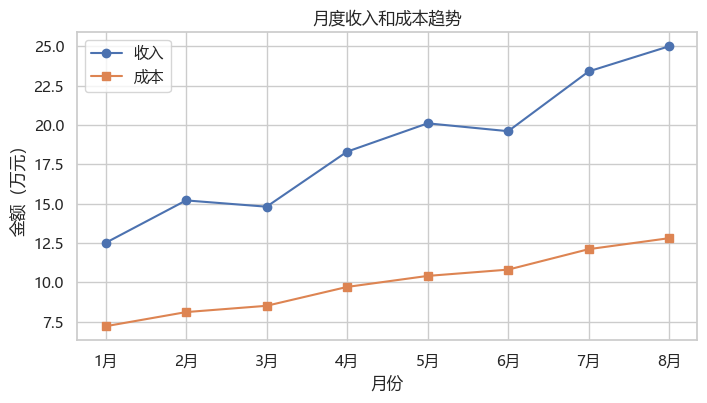

In [ ]:
# fig含义: 整个图表区域
# ax含义: 图表中的坐标轴区域
# plt.subplots()函数的参数figsize=(8, 4)表示创建一个宽8英寸、高4英寸的图表区域。
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sales["month"], sales["revenue"], marker="o", label="收入")
ax.plot(sales["month"], sales["cost"], marker="s", label="成本")

ax.set_title("月度收入和成本趋势")
ax.set_xlabel("月份")
ax.set_ylabel("金额（万元）")
ax.legend()
plt.show()


### 2.2 柱状图

柱状图适合对比不同类别或不同时间点的数值。


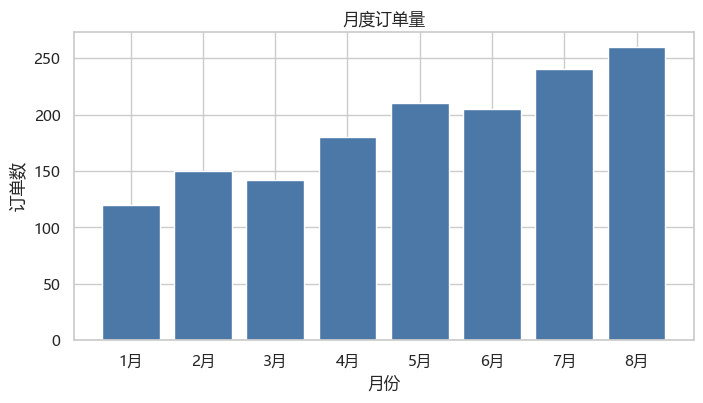

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sales["month"], sales["orders"], color="#4C78A8")

ax.set_title("月度订单量")
ax.set_xlabel("月份")
ax.set_ylabel("订单数")
plt.show()


### 2.3 水平柱状图

当类别名称较长或想强调排名时，水平柱状图很实用。


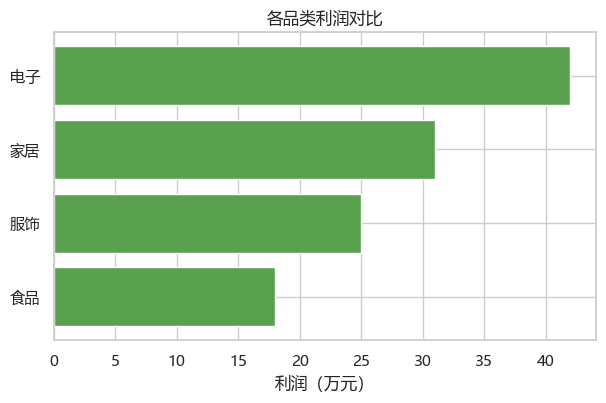

In [2]:
category_profit = pd.DataFrame({
    "category": ["电子", "服饰", "食品", "家居"],
    "profit": [42, 25, 18, 31],
}).sort_values("profit")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(category_profit["category"], category_profit["profit"], color="#59A14F")
ax.set_title("各品类利润对比")
ax.set_xlabel("利润（万元）")
plt.show()


## 三、Matplotlib 常见图表

掌握折线图和柱状图后，可以继续学习散点图、直方图、饼图和多子图。


### 3.1 散点图

散点图适合观察两个数值变量之间的关系。


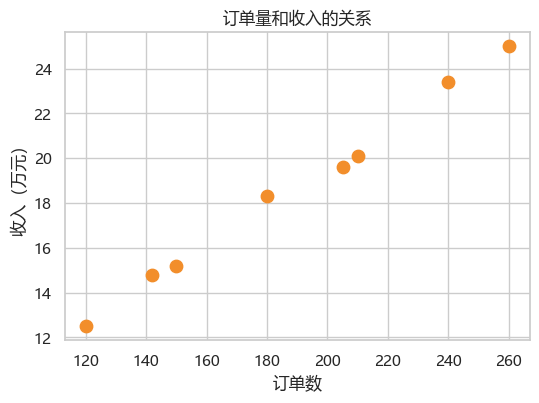

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sales["orders"], sales["revenue"], s=80, color="#F28E2B")

ax.set_title("订单量和收入的关系")
ax.set_xlabel("订单数")
ax.set_ylabel("收入（万元）")
plt.show()


### 3.2 直方图

直方图用于观察数值分布，比如价格主要集中在哪个区间。


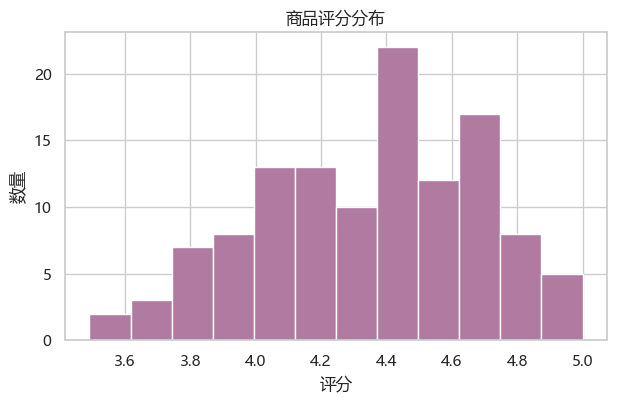

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(products["rating"], bins=12, color="#B07AA1", edgecolor="white")

ax.set_title("商品评分分布")
ax.set_xlabel("评分")
ax.set_ylabel("数量")
plt.show()


### 3.3 饼图

饼图适合展示占比，但分类过多时不建议使用。


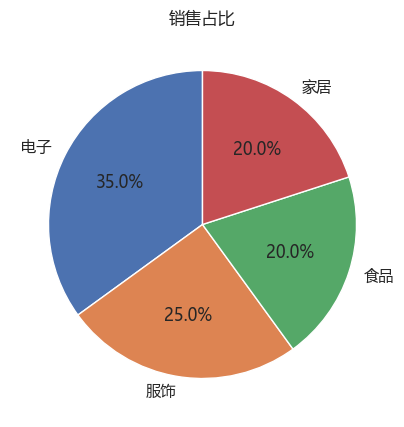

In [9]:
share = pd.Series([35, 25, 20, 20], index=["电子", "服饰", "食品", "家居"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(share, labels=share.index, autopct="%.1f%%", startangle=90)
ax.set_title("销售占比")
plt.show()


### 3.4 多子图

`plt.subplots(rows, cols)` 可以一次创建多个坐标区，适合将多张图放在一起对比。


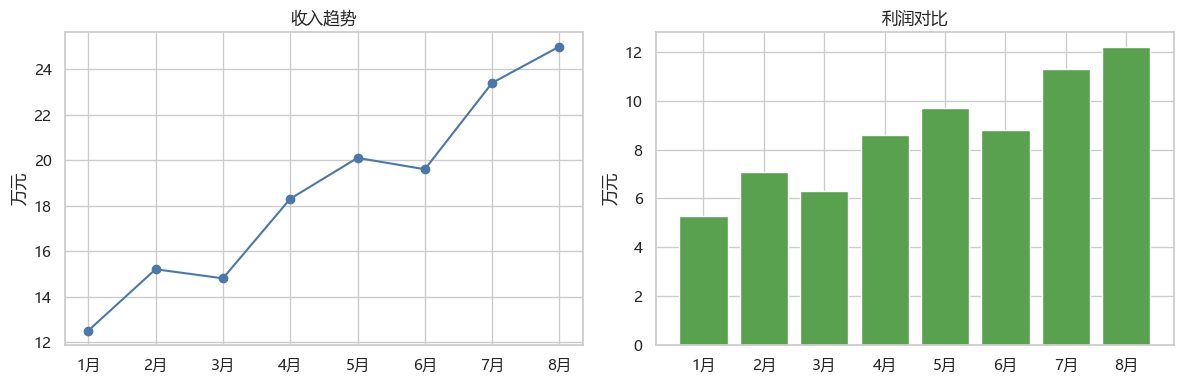

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sales["month"], sales["revenue"], marker="o", color="#4C78A8")
axes[0].set_title("收入趋势")
axes[0].set_ylabel("万元")

axes[1].bar(sales["month"], sales["profit"], color="#59A14F")
axes[1].set_title("利润对比")
axes[1].set_ylabel("万元")

plt.tight_layout()
plt.show()


## 四、Matplotlib 图表美化

一张图表至少要有标题、坐标轴名称、合适的颜色和图例。必要时可以加数值标签。


### 4.1 颜色、线型和标记


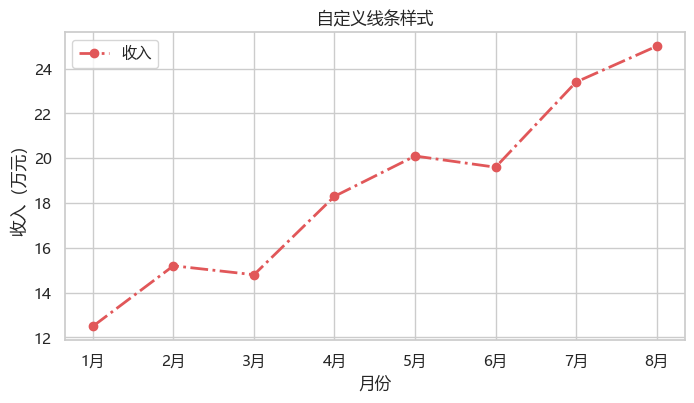

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    sales["month"],
    sales["revenue"],
    color="#E15759",
    linestyle="--",
    marker="o",
    linewidth=2,
    label="收入",
)

ax.set_title("自定义线条样式")
ax.set_xlabel("月份")
ax.set_ylabel("收入（万元）")
ax.legend()
plt.show()


### 4.2 添加数值标签


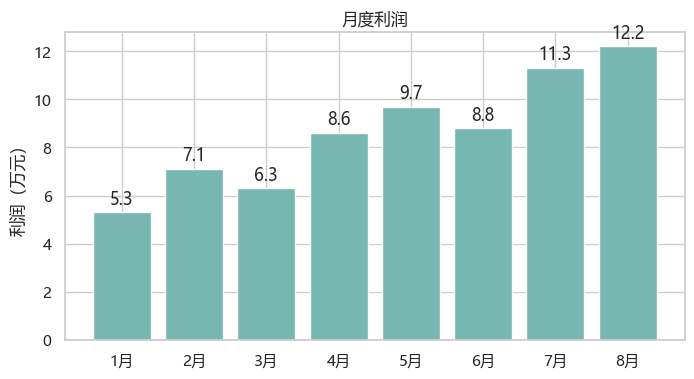

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sales["month"], sales["profit"], color="#76B7B2")

ax.set_title("月度利润")
ax.set_ylabel("利润（万元）")
ax.bar_label(bars, fmt="%.1f", padding=3)
plt.show()


### 4.3 保存图片

保存图片时常用 `fig.savefig()`。下面用注释形式演示，避免运行 notebook 时自动生成多余文件。


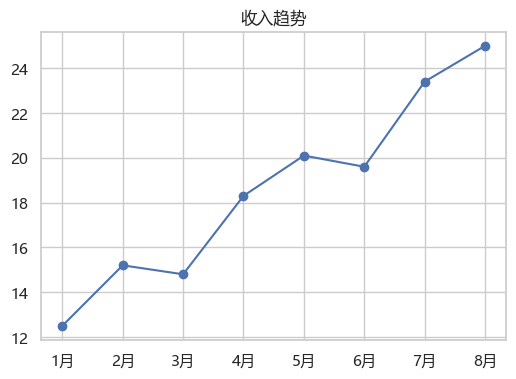

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sales["month"], sales["revenue"], marker="o")
ax.set_title("收入趋势")

# 需要保存时取消下一行注释
# fig.savefig("revenue_trend.png", dpi=150, bbox_inches="tight")

plt.show()


## 五、Seaborn 基础

Seaborn 更关注统计可视化。它的常用写法是：

```python
sns.xxxplot(data=df, x="column_x", y="column_y", hue="group")
```

其中 `data` 接收 DataFrame，`x` 和 `y` 指定列名，`hue` 用来按类别分颜色。


### 5.1 lineplot() 折线图


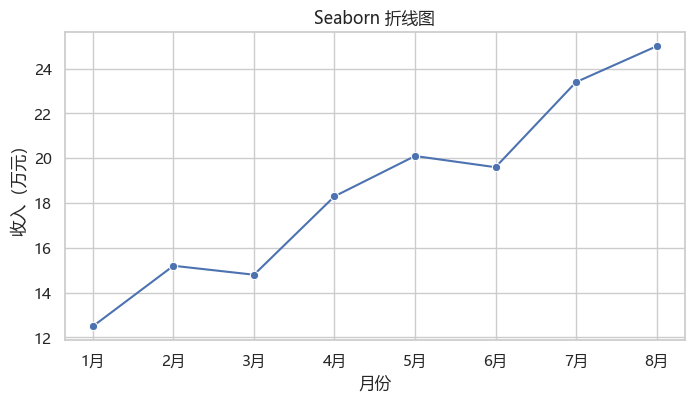

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=sales, x="month", y="revenue", marker="o", ax=ax)

ax.set_title("Seaborn 折线图")
ax.set_xlabel("月份")
ax.set_ylabel("收入（万元）")
plt.show()


### 5.2 barplot() 柱状图

Seaborn 的 `barplot()` 默认会进行统计聚合，比如计算均值。如果数据已经是每个类别一行，它也可以直接绘制。


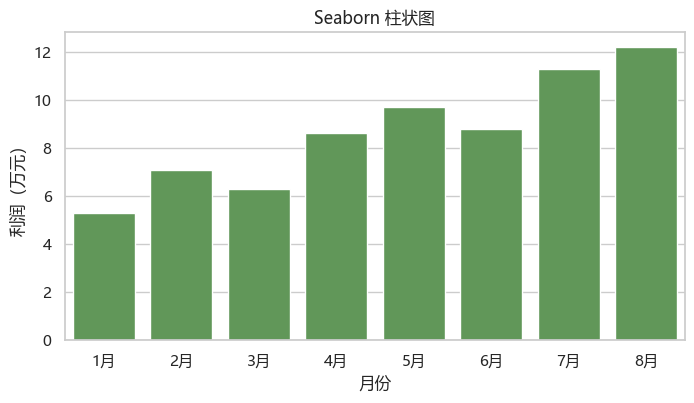

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=sales, x="month", y="profit", color="#59A14F", ax=ax)

ax.set_title("Seaborn 柱状图")
ax.set_xlabel("月份")
ax.set_ylabel("利润（万元）")
plt.show()


### 5.3 scatterplot() 散点图


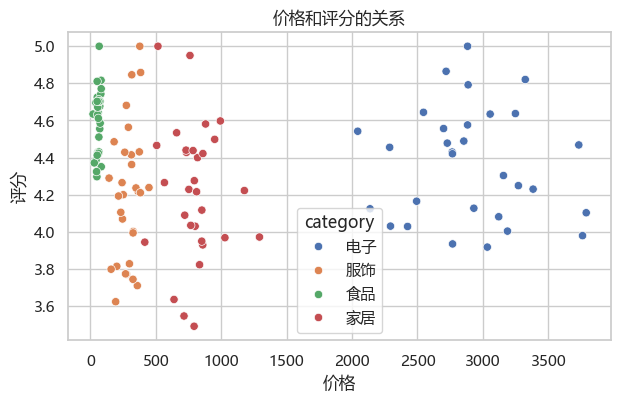

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=products, x="price", y="rating", hue="category", ax=ax)

ax.set_title("价格和评分的关系")
ax.set_xlabel("价格")
ax.set_ylabel("评分")
plt.show()


## 六、Seaborn 分布图

分布图用来观察数值变量的集中程度、偏态和离散程度。


### 6.1 histplot() 直方图


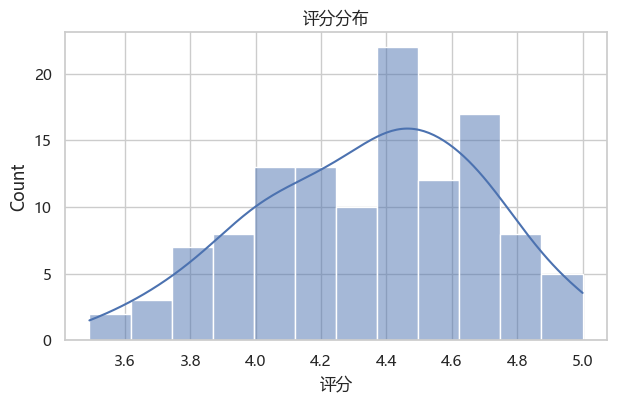

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=products, x="rating", bins=12, kde=True, ax=ax)

ax.set_title("评分分布")
ax.set_xlabel("评分")
plt.show()


### 6.2 kdeplot() 密度图

KDE 图可以把分布表现成更平滑的曲线。


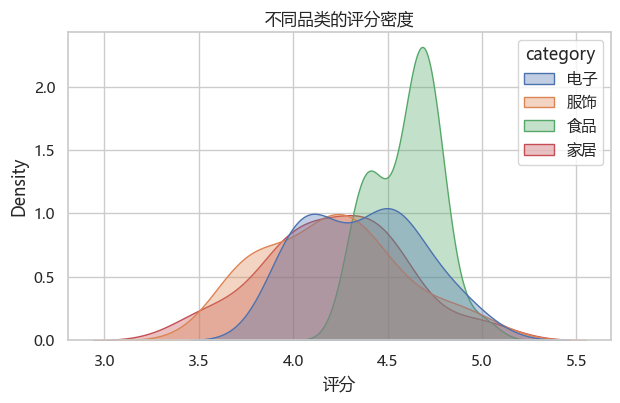

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=products, x="rating", hue="category", fill=True, common_norm=False, alpha=0.35, ax=ax)

ax.set_title("不同品类的评分密度")
ax.set_xlabel("评分")
plt.show()


### 6.3 boxplot() 箱线图

箱线图适合对比不同组的分布，能看到中位数、四分位和异常值。


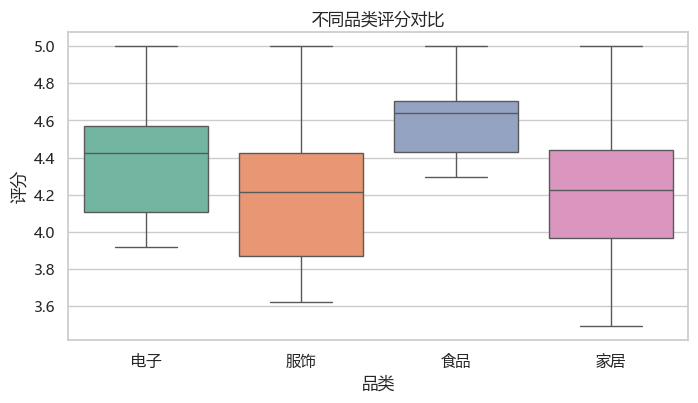

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=products, x="category", y="rating", hue="category", palette="Set2", legend=False, ax=ax)

ax.set_title("不同品类评分对比")
ax.set_xlabel("品类")
ax.set_ylabel("评分")
plt.show()


### 6.4 violinplot() 小提琴图

小提琴图结合了箱线图和密度图，更适合观察分布形状。


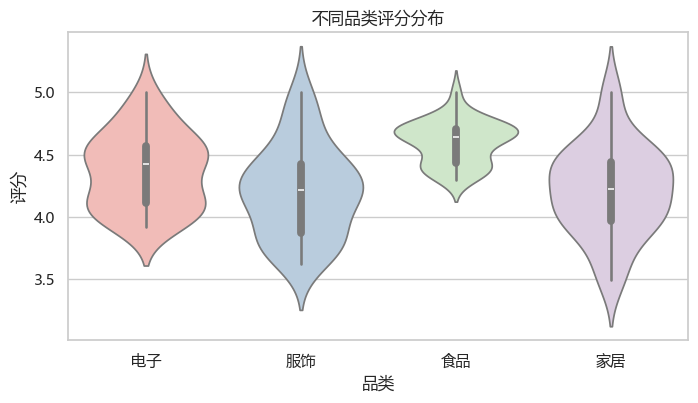

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=products, x="category", y="rating", hue="category", palette="Pastel1", legend=False, ax=ax)

ax.set_title("不同品类评分分布")
ax.set_xlabel("品类")
ax.set_ylabel("评分")
plt.show()


## 七、Seaborn 关系图和统计图

关系图用来观察变量之间的关系，比如相关性、趋势和分组差异。


### 7.1 regplot() 回归趋势图


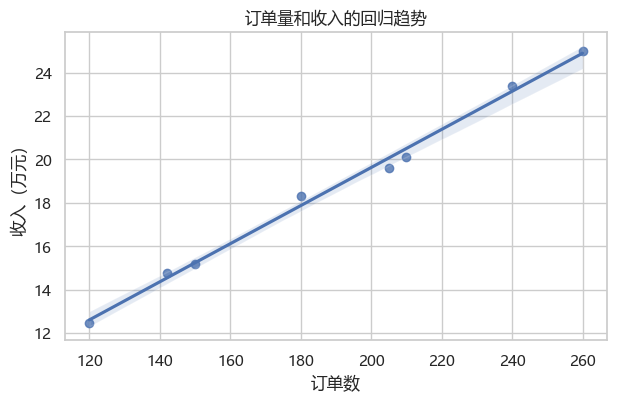

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(data=sales, x="orders", y="revenue", ax=ax)

ax.set_title("订单量和收入的回归趋势")
ax.set_xlabel("订单数")
ax.set_ylabel("收入（万元）")
plt.show()


### 7.2 heatmap() 热力图

热力图常用来展示相关系数或二维表格数值。


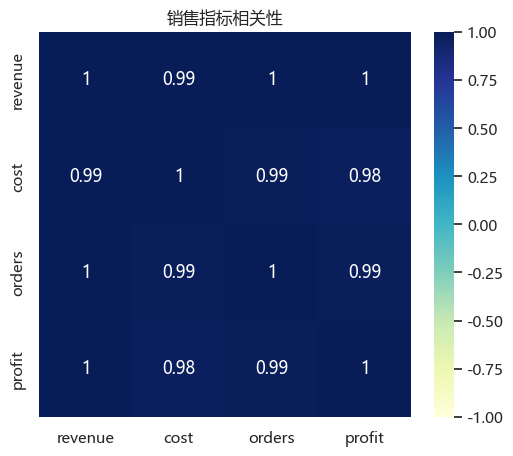

In [26]:
corr = sales[["revenue", "cost", "orders", "profit"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="YlGnBu", vmin=-1, vmax=1, ax=ax)

ax.set_title("销售指标相关性")
plt.show()


### 7.3 pairplot() 多变量关系图

`pairplot()` 会自动绘制多个数值列之间的两两关系，适合做探索性分析。


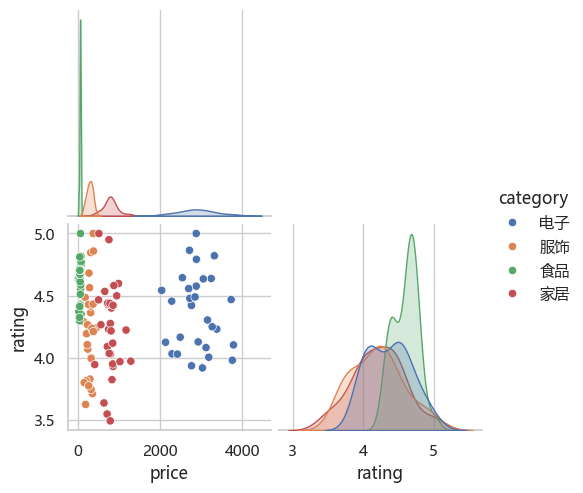

In [27]:
sns.pairplot(products, vars=["price", "rating"], hue="category", corner=True)
plt.show()


## 八、Seaborn 分面图

分面图用于按类别拆分多张小图，便于比较不同分组下的数据形态。


### 8.1 catplot() 分类图


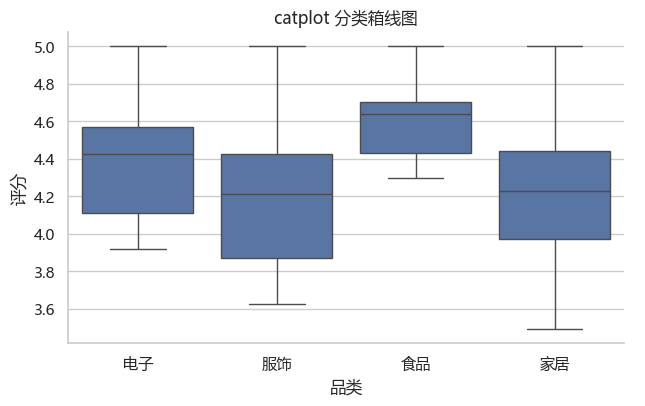

In [28]:
sns.catplot(data=products, x="category", y="rating", kind="box", height=4, aspect=1.6)
plt.title("catplot 分类箱线图")
plt.xlabel("品类")
plt.ylabel("评分")
plt.show()


### 8.2 relplot() 关系分面图


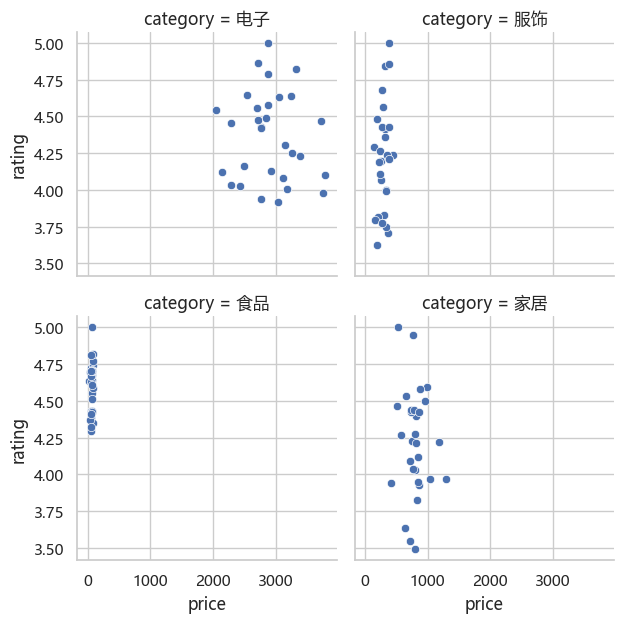

In [29]:
sns.relplot(data=products, x="price", y="rating", col="category", col_wrap=2, height=3.2)
plt.show()


## 九、两个库怎么选

Matplotlib 和 Seaborn 不是二选一，而是经常搭配使用。


### 9.1 选型建议

- 想完全控制图表细节：用 Matplotlib。
- 想快速做统计图：用 Seaborn。
- 想先画出来再微调：用 Seaborn 画图，再用 Matplotlib 的 `ax` 调整标题、坐标轴、图例等。


### 9.2 Seaborn 画图，Matplotlib 微调


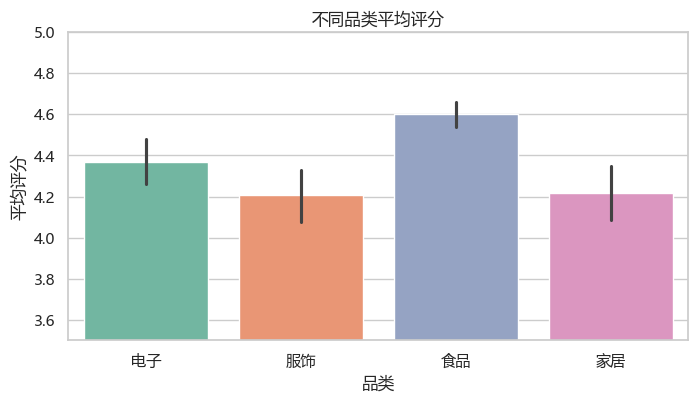

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=products, x="category", y="rating", hue="category", palette="Set2", legend=False, ax=ax)

ax.set_title("不同品类平均评分")
ax.set_xlabel("品类")
ax.set_ylabel("平均评分")
ax.set_ylim(3.5, 5.0)
plt.show()


## 十、学习小结

这份 notebook 建议按下面的顺序掌握：

1. 先理解 Matplotlib 的 `fig` 和 `ax`。
2. 熟练折线图、柱状图、散点图、直方图。
3. 学会标题、坐标轴、图例、颜色和标签的基本美化。
4. 再用 Seaborn 快速绘制统计图：`histplot`、`boxplot`、`violinplot`、`heatmap`、`pairplot`。
5. 最后练习“Seaborn 出图 + Matplotlib 微调”这种实战写法。

下一步可以将 pandas 和可视化结合起来，做一份小型数据分析报告：数据清洗 -> 分组统计 -> 可视化 -> 结论。
